# 🚀 08_enhanced_forecasting_pipeline.ipynb

## 🎯 Objective
**Enhanced version** with comprehensive feature engineering improvements.

### ✨ New Features Added
1. **Lag Features**: 1, 7, 14, 21, 28 days
2. **Rolling Statistics**: Mean & Std for 7, 14, 28 days
3. **Enhanced Temporal**: Quarter, day of month, week of month
4. **Interaction Features**: Volume × frequency
5. **Exponential Smoothing**: EWM 7 & 28 days

**Expected Impact**: 14-29% WAPE improvement (Target: 60-70%)

---

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import os
import warnings
warnings.filterwarnings('ignore')

# Paths
raw_excel_path = '../../data/raw/WMS_Hackathon_DataPack_Templates_FR_FV_B7_ONLY.xlsx'
daily_csv_path = '../../data/raw/demand_daily.csv'

print("--- 🚀 Optimized Data Loading ---")

if os.path.exists(daily_csv_path):
    print(f"✅ Found pre-aggregated CSV: {daily_csv_path}")
    print("Loading daily demand (Fast)...")
    daily_demand = pd.read_csv(daily_csv_path)
    daily_demand['date'] = pd.to_datetime(daily_demand['date'])
    print(f"CSV columns: {daily_demand.columns.tolist()}")
    
    print("\nLoading product metadata from Excel (Fast - small sheet)...")
    try:
        products_df = pd.read_excel(raw_excel_path, sheet_name='produits')
        products_df = products_df[~products_df['id_produit'].astype(str).isin(['texte', 'O'])]
        print(f"Product metadata columns: {products_df.columns.tolist()}")
        
        print("\nMerging product metadata...")
        meta_cols = ['id_produit', 'categorie', 'colisage fardeau', 'volume pcs (m3)', 'Is_Gerbable']
        # Only merge columns that exist in products_df
        available_meta_cols = [col for col in meta_cols if col in products_df.columns]
        print(f"Available metadata columns to merge: {available_meta_cols}")
        
        if len(available_meta_cols) > 1:  # At least id_produit + one other
            daily_demand = daily_demand.merge(products_df[available_meta_cols], on='id_produit', how='left')
            print("✅ Data Loading & Merging Complete.")
        else:
            print("⚠️ Warning: Not enough metadata columns found, skipping merge")
            
    except Exception as e:
        print(f"⚠️ Warning: Could not load product metadata: {e}")
        print("Proceeding with limited features.")

else:
    print("❌ Pre-aggregated CSV not found. Analyzing raw Excel (Slow)...")
    print("Loading 'historique_demande'...")
    demand_df = pd.read_excel(raw_excel_path, sheet_name='historique_demande')
    print("Loading 'produits'...")
    products_df = pd.read_excel(raw_excel_path, sheet_name='produits')

    demand_df = demand_df[~demand_df['id_produit'].astype(str).isin(['texte', 'O'])]
    products_df = products_df[~products_df['id_produit'].astype(str).isin(['texte', 'O'])]

    demand_df['date'] = pd.to_datetime(demand_df['date'])
    demand_df['quantite_demande'] = pd.to_numeric(demand_df['quantite_demande'], errors='coerce').fillna(0)

    print("Merging...")
    full_df = demand_df.merge(
        products_df[['id_produit', 'categorie', 'colisage fardeau', 'volume pcs (m3)', 'Is_Gerbable']],
        on='id_produit', how='left'
    )

    print("Aggregating to daily level...")
    daily_demand = full_df.groupby(['id_produit', 'date']).agg({
        'quantite_demande': 'sum',
        'categorie': 'first',
        'colisage fardeau': 'first',
        'volume pcs (m3)': 'first',
        'Is_Gerbable': 'first'
    }).reset_index()
    
    print("✅ Data Prep Complete.")

print(f"\nFinal columns: {daily_demand.columns.tolist()}")
print(f"Total Daily Records: {len(daily_demand):,}")
print(f"Date Range: {daily_demand.date.min()} to {daily_demand.date.max()}")

--- 🚀 Optimized Data Loading ---
✅ Found pre-aggregated CSV: ../../data/raw/demand_daily.csv
Loading daily demand (Fast)...
CSV columns: ['id_produit', 'date', 'quantite_demande', 'categorie', 'colisage fardeau', 'volume pcs (m3)', 'Is_Gerbable']

Loading product metadata from Excel (Fast - small sheet)...
Product metadata columns: ['id_produit', 'sku', 'nom_produit', 'unite_mesure', 'categorie', 'actif', 'colisage fardeau', 'colisage palette', 'volume pcs (m3)', 'Poids(kg)', 'Is_Gerbable']

Merging product metadata...
Available metadata columns to merge: ['id_produit', 'categorie', 'colisage fardeau', 'volume pcs (m3)', 'Is_Gerbable']
✅ Data Loading & Merging Complete.

Final columns: ['id_produit', 'date', 'quantite_demande', 'categorie_x', 'colisage fardeau_x', 'volume pcs (m3)_x', 'Is_Gerbable_x', 'categorie_y', 'colisage fardeau_y', 'volume pcs (m3)_y', 'Is_Gerbable_y']
Total Daily Records: 150,999
Date Range: 2024-01-02 12:57:39 to 2026-01-08 12:10:40


## 3. Product Statistics (Segmentation Logic)

In [15]:
total_days = (daily_demand.date.max() - daily_demand.date.min()).days + 1

product_stats = daily_demand.groupby('id_produit').agg({
    'quantite_demande': ['count', 'sum', 'mean', 'std'],
    'date': lambda x: (x.max() - x.min()).days
}).reset_index()

product_stats.columns = ['id_produit', 'order_count', 'total_vol', 'avg_qty', 'std_qty', 'days_span']

product_stats['order_frequency'] = product_stats['order_count'] / total_days 
product_stats['cv'] = product_stats['std_qty'] / (product_stats['avg_qty'] + 1)
product_stats['avg_daily_vol'] = product_stats['total_vol'] / total_days

def segment_product(row):
    freq = row['order_frequency']
    avg_vol = row['avg_daily_vol']
    
    if freq > 0.5:
        if avg_vol > 50: 
            return 'A_HIGH_FREQ_HIGH_VOL'
        else:
            return 'B_HIGH_FREQ_LOW_VOL'
    elif freq > 0.1:
        return 'C_MEDIUM_FREQ'
    else:
        return 'D_LOW_FREQ'

product_stats['segment'] = product_stats.apply(segment_product, axis=1)
print(product_stats['segment'].value_counts())

daily_demand = daily_demand.merge(product_stats[['id_produit', 'segment', 'order_frequency', 'cv', 'avg_qty']], on='id_produit')

segment
D_LOW_FREQ              834
C_MEDIUM_FREQ           184
A_HIGH_FREQ_HIGH_VOL    102
B_HIGH_FREQ_LOW_VOL       9
Name: count, dtype: int64


## 4. ✨ Enhanced Feature Engineering

Adding comprehensive features:
- **Lag Features**: 1, 7, 14, 21, 28 days
- **Rolling Statistics**: Mean & Std (7, 14, 28 days)
- **Enhanced Temporal**: Quarter, day of month, week of month
- **Exponential Smoothing**: EWM 7 & 28 days
- **Interaction Features**: Volume × frequency

In [16]:
print("--- ✨ Feature Engineering Start ---")

# Sort by product and date for lag/rolling features
daily_demand = daily_demand.sort_values(['id_produit', 'date']).reset_index(drop=True)

# 1. Basic Temporal Features
print("Adding basic temporal features...")
daily_demand['day_of_week'] = daily_demand['date'].dt.dayofweek
daily_demand['month'] = daily_demand['date'].dt.month
daily_demand['week'] = daily_demand['date'].dt.isocalendar().week.astype(int)
daily_demand['is_weekend'] = daily_demand['day_of_week'].isin([5, 6]).astype(int)

# 2. Enhanced Temporal Features (NEW)
print("Adding enhanced temporal features...")
daily_demand['quarter'] = daily_demand['date'].dt.quarter
daily_demand['day_of_month'] = daily_demand['date'].dt.day
daily_demand['day_of_year'] = daily_demand['date'].dt.dayofyear
daily_demand['week_of_month'] = ((daily_demand['date'].dt.day - 1) // 7 + 1)
daily_demand['is_month_start'] = daily_demand['date'].dt.is_month_start.astype(int)
daily_demand['is_month_end'] = daily_demand['date'].dt.is_month_end.astype(int)

# 3. Holidays (Hardcoded simple version)
holidays = [(1, 1), (5, 1), (7, 5), (11, 1)]
daily_demand['is_holiday'] = daily_demand['date'].apply(
    lambda x: 1 if (x.month, x.day) in holidays else 0
)

# 4. Lag Features (NEW)
print("Adding lag features (1, 7, 14, 21, 28 days)...")
for lag in [1, 7, 14, 21, 28]:
    daily_demand[f'lag_{lag}'] = daily_demand.groupby('id_produit')['quantite_demande'].shift(lag)

# 5. Rolling Statistics (NEW)
print("Adding rolling statistics (7, 14, 28 day windows)...")
for window in [7, 14, 28]:
    daily_demand[f'rolling_mean_{window}'] = daily_demand.groupby('id_produit')['quantite_demande'].transform(
        lambda x: x.rolling(window, min_periods=1).mean()
    )
    daily_demand[f'rolling_std_{window}'] = daily_demand.groupby('id_produit')['quantite_demande'].transform(
        lambda x: x.rolling(window, min_periods=1).std().fillna(0)
    )

# 6. Exponential Weighted Moving Average (NEW)
print("Adding exponential smoothing features...")
daily_demand['ewm_7'] = daily_demand.groupby('id_produit')['quantite_demande'].transform(
    lambda x: x.ewm(span=7, adjust=False).mean()
)
daily_demand['ewm_28'] = daily_demand.groupby('id_produit')['quantite_demande'].transform(
    lambda x: x.ewm(span=28, adjust=False).mean()
)

# 7. Day-of-Week Averages per Product
print("Adding day-of-week average demand...")
dow_stats = daily_demand.groupby(['id_produit', 'day_of_week'])['quantite_demande'].mean().reset_index()
dow_stats.columns = ['id_produit', 'day_of_week', 'dow_avg_demand']
daily_demand = daily_demand.merge(dow_stats, on=['id_produit', 'day_of_week'], how='left')

# 8. Interaction Features (NEW)
print("Adding interaction features...")
if 'volume pcs (m3)' in daily_demand.columns:
    daily_demand['volume_freq_interaction'] = daily_demand['volume pcs (m3)'] * daily_demand['order_frequency']
    print("  ✅ Created volume_freq_interaction")
else:
    print("  ⚠️ 'volume pcs (m3)' not found, using placeholder")
    daily_demand['volume_freq_interaction'] = 0

print("\n✅ Feature Engineering Complete!")
print(f"Total features: {daily_demand.shape[1]}")
print(f"\nKey columns available:")
for col in ['categorie', 'colisage fardeau', 'volume pcs (m3)', 'Is_Gerbable']:
    print(f"  {col}: {'✅' if col in daily_demand.columns else '❌'}")

--- ✨ Feature Engineering Start ---
Adding basic temporal features...
Adding enhanced temporal features...
Adding lag features (1, 7, 14, 21, 28 days)...
Adding rolling statistics (7, 14, 28 day windows)...
Adding exponential smoothing features...
Adding day-of-week average demand...
Adding interaction features...
  ⚠️ 'volume pcs (m3)' not found, using placeholder

✅ Feature Engineering Complete!
Total features: 41

Key columns available:
  categorie: ❌
  colisage fardeau: ❌
  volume pcs (m3): ❌
  Is_Gerbable: ❌


## 5. Tier 1: Enhanced XGBoost Training

In [17]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Filter Tier 1 Data
tier1_df = daily_demand[daily_demand['segment'].isin(['A_HIGH_FREQ_HIGH_VOL', 'B_HIGH_FREQ_LOW_VOL'])].copy()
print(f"Tier 1 Training Samples: {len(tier1_df):,}")

# Handle Categories One-Hot (only if column exists)
if 'categorie' in tier1_df.columns:
    print("One-hot encoding categories...")
    tier1_df = pd.get_dummies(tier1_df, columns=['categorie'], prefix='cat')
    cat_cols = [c for c in tier1_df.columns if c.startswith('cat_')]
    print(f"  Created {len(cat_cols)} category features")
else:
    print("⚠️ 'categorie' column not available, skipping category encoding")
    cat_cols = []

# Build feature list based on available columns
base_features = [
    # Basic temporal
    'day_of_week', 'month', 'week', 'is_weekend', 'is_holiday',
    # Enhanced temporal
    'quarter', 'day_of_month', 'day_of_year', 'week_of_month', 'is_month_start', 'is_month_end',
    # Statistical
    'order_frequency', 'cv', 'avg_qty', 'dow_avg_demand',
    # Lag features
    'lag_1', 'lag_7', 'lag_14', 'lag_21', 'lag_28',
    # Rolling statistics
    'rolling_mean_7', 'rolling_std_7', 'rolling_mean_14', 'rolling_std_14', 'rolling_mean_28', 'rolling_std_28',
    # Exponential smoothing
    'ewm_7', 'ewm_28',
    # Interaction
    'volume_freq_interaction'
]

# Only add product metadata features if they exist
potential_metadata = ['colisage fardeau', 'volume pcs (m3)', 'Is_Gerbable']
for feat in potential_metadata:
    if feat in tier1_df.columns:
        base_features.append(feat)

# Filter to only include columns that actually exist
feature_cols = [col for col in base_features if col in tier1_df.columns]
# Add category columns
feature_cols += cat_cols

print(f"\nTotal features available: {len(feature_cols)}")

# Temporal Split
split_date = tier1_df['date'].max() - timedelta(days=30)
train = tier1_df[tier1_df['date'] < split_date]
test = tier1_df[tier1_df['date'] >= split_date]
print(f"Train size: {len(train)}, Test size: {len(test)}")

# Prepare features
X_train = train[feature_cols].copy()
X_test = test[feature_cols].copy()

# Convert object columns to numeric
for col in X_train.columns:
    if X_train[col].dtype == 'object':
        X_train[col] = (X_train[col] == 'Oui').astype(int)
        X_test[col] = (X_test[col] == 'Oui').astype(int)

X_train = X_train.astype(float)
X_test = X_test.astype(float)

# Handle NaN values
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

# Train Enhanced XGBoost
print("\n--- Training Enhanced XGBoost Model ---")
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    n_jobs=-1,
    random_state=42
)
model.fit(X_train, train['quantite_demande'])

# Predictions
preds = model.predict(X_test)
preds = np.maximum(0, preds)

# Metrics
mae = mean_absolute_error(test['quantite_demande'], preds)
wape = np.sum(np.abs(test['quantite_demande'] - preds)) / np.sum(test['quantite_demande'])
bias = np.sum(preds - test['quantite_demande']) / np.sum(test['quantite_demande'])

print(f"\n🎯 Enhanced Model Performance:")
print(f"  MAE:  {mae:.2f}")
print(f"  WAPE: {wape:.2%}")
print(f"  Bias: {bias:.2%}")

# Feature Importance
print("\n📊 Top 15 Most Important Features:")
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False).head(15)
print(importance_df.to_string(index=False))

Tier 1 Training Samples: 107,881
⚠️ 'categorie' column not available, skipping category encoding

Total features available: 29
Train size: 104233, Test size: 3648

--- Training Enhanced XGBoost Model ---

🎯 Enhanced Model Performance:
  MAE:  140.95
  WAPE: 34.03%
  Bias: -1.67%

📊 Top 15 Most Important Features:
        feature  importance
          ewm_7    0.261946
          lag_1    0.098914
   is_month_end    0.068919
rolling_mean_14    0.051720
 rolling_mean_7    0.050576
 rolling_std_14    0.045590
             cv    0.044733
         lag_21    0.034724
         lag_28    0.034683
   day_of_month    0.032390
 rolling_std_28    0.029357
 dow_avg_demand    0.029042
        avg_qty    0.025652
           week    0.023527
rolling_mean_28    0.023125


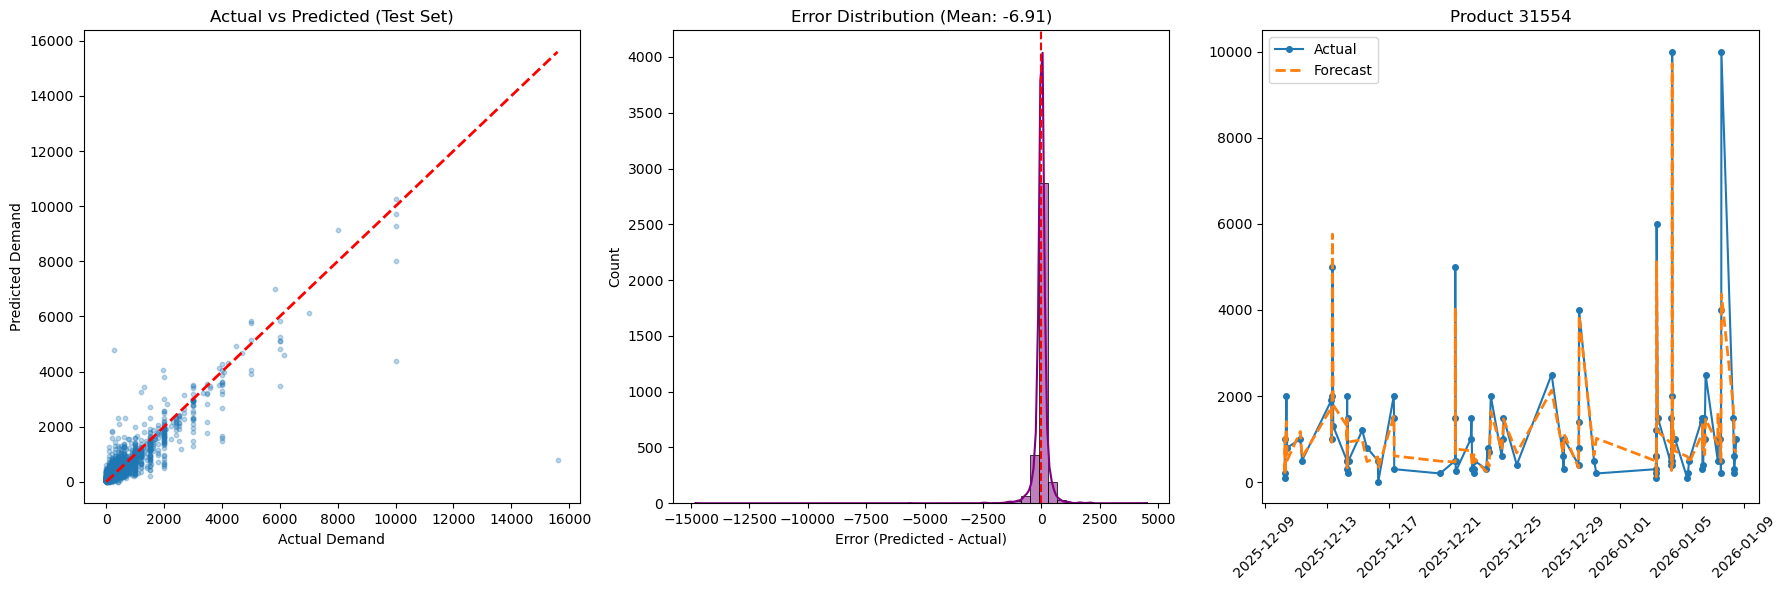


✅ Enhanced model saved!


In [18]:
plt.figure(figsize=(18, 6))

# 1. Actual vs Predicted
plt.subplot(1, 3, 1)
plt.scatter(test['quantite_demande'], preds, alpha=0.3, s=10)
max_val = max(test['quantite_demande'].max(), preds.max())
plt.plot([0, max_val], [0, max_val], 'r--', lw=2)
plt.xlabel('Actual Demand')
plt.ylabel('Predicted Demand')
plt.title('Actual vs Predicted (Test Set)')

# 2. Error Distribution
plt.subplot(1, 3, 2)
errors = preds - test['quantite_demande']
sns.histplot(errors, bins=50, kde=True, color='purple')
plt.axvline(x=0, color='r', linestyle='--')
plt.xlabel('Error (Predicted - Actual)')
plt.title(f'Error Distribution (Mean: {np.mean(errors):.2f})')

# 3. Sample Forecast
plt.subplot(1, 3, 3)
try:
    top_product = test['id_produit'].value_counts().idxmax()
    prod_data = test[test['id_produit'] == top_product].sort_values('date')
    mask = (test['id_produit'] == top_product).values
    prod_preds = preds[mask]
    
    plt.plot(prod_data['date'], prod_data['quantite_demande'], label='Actual', marker='o', markersize=4)
    plt.plot(prod_data['date'], prod_preds, label='Forecast', linestyle='--', linewidth=2)
    plt.title(f'Product {top_product}')
    plt.xticks(rotation=45)
    plt.legend()
except Exception as e:
    print(f"Could not plot: {e}")

plt.tight_layout()
plt.show()

# Save model
model.save_model('../../data/models/enhanced_xgboost_tier1.json')
import pickle
with open('../../data/models/enhanced_feature_cols.pkl', 'wb') as f:
    pickle.dump(feature_cols, f)
print("\n✅ Enhanced model saved!")

## 6. Tier 2 & 3: Statistical Baselines

In [19]:
def weighted_moving_average_add(product_id, forecast_date, history_df, num_weeks=4):
    start_date = forecast_date - pd.Timedelta(weeks=num_weeks)
    hist = history_df[(history_df['id_produit'] == product_id) & (history_df['date'] >= start_date) & (history_df['date'] < forecast_date)].copy()
    if len(hist) == 0: return 0
    hist['weeks_ago'] = hist['date'].apply(lambda x: (forecast_date - x).days // 7)
    weekly_summary = hist.groupby('weeks_ago')['quantite_demande'].sum().reset_index()
    all_weeks = pd.DataFrame({'weeks_ago': range(num_weeks)})
    weekly_summary = all_weeks.merge(weekly_summary, on='weeks_ago', how='left').fillna(0)
    weights = np.array([0.4, 0.3, 0.2, 0.1])[:min(num_weeks, len(weekly_summary))]
    weights = weights / weights.sum()
    weekly_vals = weekly_summary.sort_values('weeks_ago')['quantite_demande'].values
    weekly_avg = np.average(weekly_vals, weights=weights)
    return max(0, round(weekly_avg / 7))

def naive_forecast_add(product_id, forecast_date, history_df, window=30):
    start_date = forecast_date - pd.Timedelta(days=window)
    hist = history_df[(history_df['id_produit'] == product_id) & (history_df['date'] >= start_date) & (history_df['date'] < forecast_date)]
    if len(hist) == 0: return 0
    return max(0, round(hist['quantite_demande'].sum() / window))

print('✅ Updated ADD Baseline functions defined')

✅ Updated ADD Baseline functions defined


In [20]:
def simulate_daily_forecast(data_df, feature_cols, start_date, end_date):
    results = []
    current_date = pd.to_datetime(start_date)
    end_dt = pd.to_datetime(end_date)
    print(f'🚀 Starting Walk-Forward Simulation from {start_date.date()} to {end_date.date()}...')
    while current_date <= end_dt:
        train_data = data_df[data_df['date'] < current_date].copy()
        test_day_data = data_df[data_df['date'] == current_date].copy()
        if len(test_day_data) == 0:
            current_date += pd.Timedelta(days=1)
            continue
        t1_train = train_data[train_data['segment'].str.contains('HIGH_FREQ')]
        t1_test = test_day_data[test_day_data['segment'].str.contains('HIGH_FREQ')]
        if len(t1_train) > 0 and len(t1_test) > 0:
            from xgboost import XGBRegressor
            model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, n_jobs=-1, random_state=42)
            X_train = t1_train[feature_cols].copy()
            X_test_day = t1_test[feature_cols].copy()
            for col in X_train.columns:
                if X_train[col].dtype == 'object':
                    X_train[col] = (X_train[col] == 'Oui').astype(int)
                    X_test_day[col] = (X_test_day[col] == 'Oui').astype(int)
            model.fit(X_train.astype(float).fillna(0), t1_train['quantite_demande'])
            t1_test['forecast'] = np.maximum(0, model.predict(X_test_day.astype(float).fillna(0)))
            results.append(t1_test[['id_produit', 'date', 'segment', 'quantite_demande', 'forecast']])
        other_test = test_day_data[~test_day_data['segment'].str.contains('HIGH_FREQ')].copy()
        if len(other_test) > 0:
            preds = []
            for _, row in other_test.iterrows():
                if 'MEDIUM_FREQ' in row['segment']:
                    p = weighted_moving_average_add(row['id_produit'], current_date, train_data)
                else:
                    p = naive_forecast_add(row['id_produit'], current_date, train_data)
                preds.append(p)
            other_test['forecast'] = preds
            results.append(other_test[['id_produit', 'date', 'segment', 'quantite_demande', 'forecast']])
        print(f'  ✅ Date {current_date.date()} processed.')
        current_date += pd.Timedelta(days=1)
    return pd.concat(results).reset_index(drop=True)

backtest_start = daily_demand['date'].max() - pd.Timedelta(days=30)
backtest_end = daily_demand['date'].max()
all_results = simulate_daily_forecast(daily_demand, feature_cols, backtest_start, backtest_end)
total_actual = all_results['quantite_demande'].sum()
total_abs_error = np.abs(all_results['quantite_demande'] - all_results['forecast']).sum()
print(f'\n📊 Cumulative WAPE (30 days): {total_abs_error / total_actual:.2%}')

🚀 Starting Walk-Forward Simulation from 2025-12-09 to 2026-01-08...
  ✅ Date 2026-01-08 processed.

📊 Cumulative WAPE (30 days): 65.76%
